In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("data/churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Observations:  
- Most of the customers are not senior citizens.
- Average tenure with company is 32 months.
- Average monthly charges are $65 which has great variation.

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## EDA

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

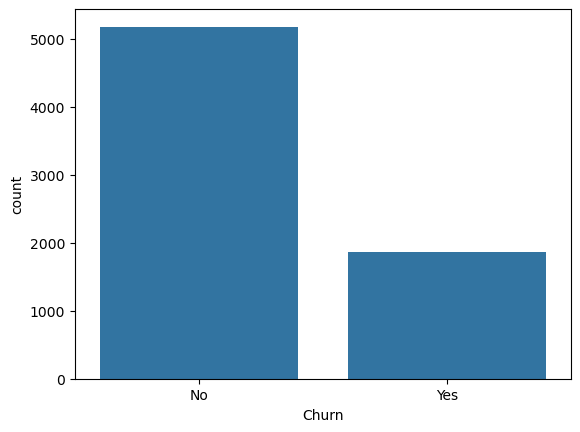

<Figure size 640x480 with 0 Axes>

In [10]:
sns.countplot(x= 'Churn', data= df)
plt.show()
plt.savefig(
    "screenshots/churn_distribution.png"
)

### Observations
- Most customers stay than leave.

In [11]:
num_cols = ["tenure", "MonthlyCharges"]

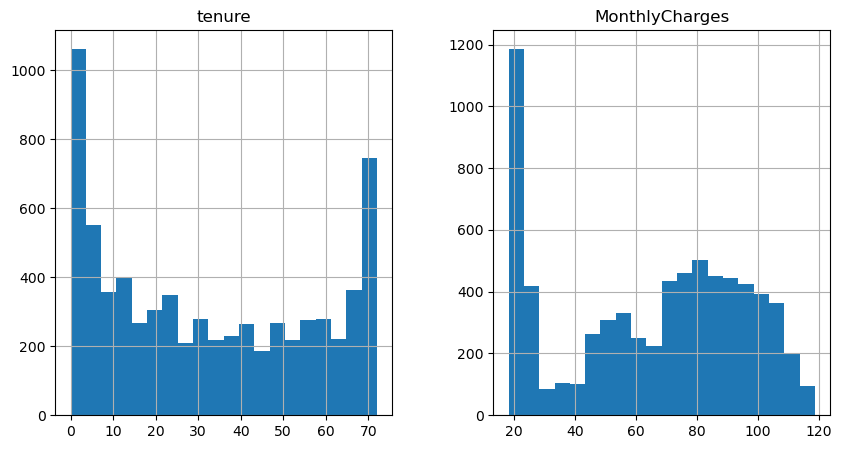

In [12]:
df[num_cols].hist( figsize = (10,5), bins = 20)
plt.savefig(
    "screenshots/tenure_&_monthlycharges.png"
)

### Observations
- More than 1000 peole are new customers, also around 700 people are old customers.
- Mostly the monthly charges are low.

## Churn vs Tenure

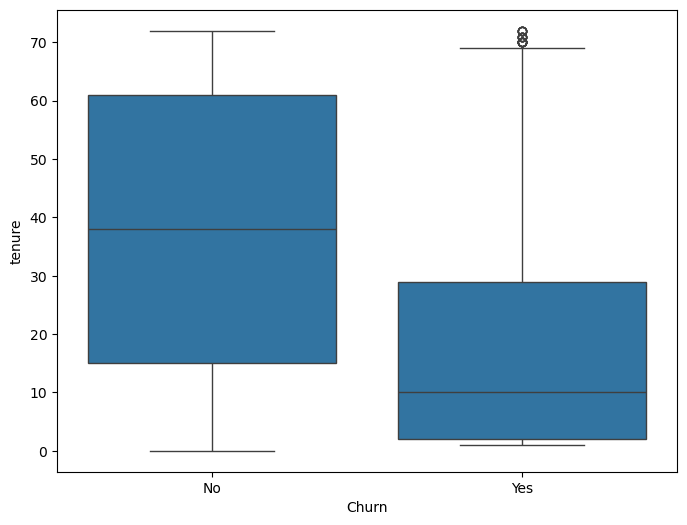

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize = (8,6))
sns.boxplot( x = "Churn", y = "tenure", data = df)
plt.show()
plt.savefig(
    "screenshots/churn_vs_tenure.png"
)

### Observation:
- Customers who have lower tenure, means are new tend to leave more.

## Churn vs Monthly Charges

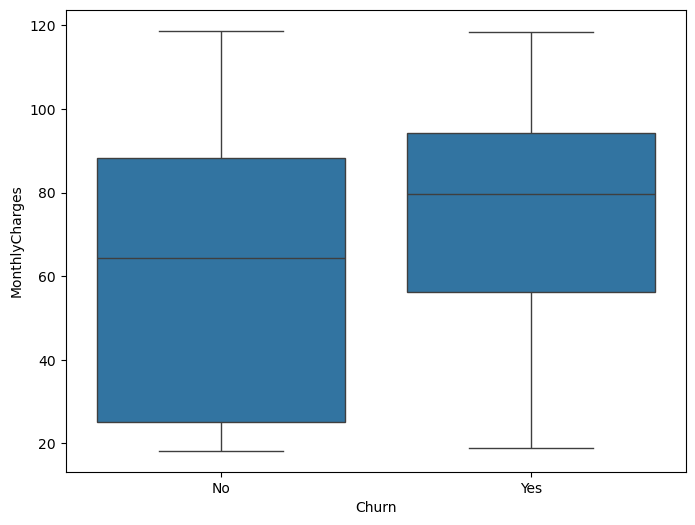

In [14]:
plt.figure(figsize = (8,6))

sns.boxplot( x = "Churn", y = "MonthlyCharges", data = df)
plt.savefig(
    "screenshots/monthlycharges_vs_churn.png"
)
plt.show()

### Observation:
- Customers with higher monthly charges tend to leave more than with lower monthly bills.

## Contract Type Analysis

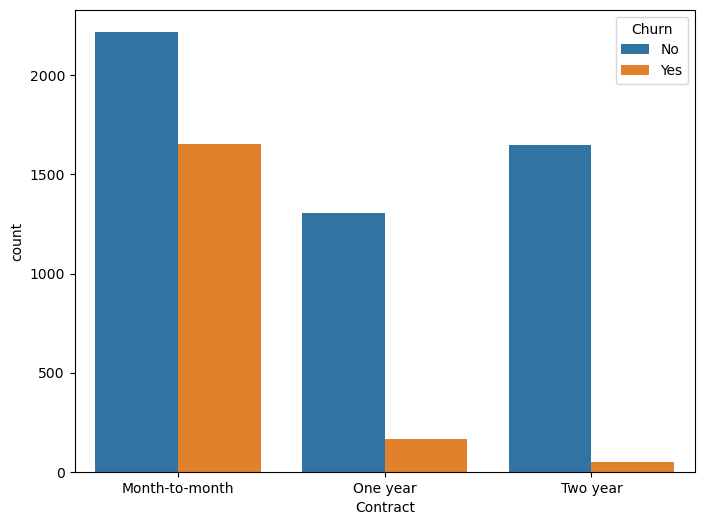

In [15]:
plt.figure(figsize=(8,6))

sns.countplot( x="Contract", hue="Churn", data=df)
plt.savefig(
    "screenshots/monthlycharges_vs_churn.png"
)
plt.show()

### Observation:
- Month-to-month customers tend to leave more.

## Internet Service Analysis

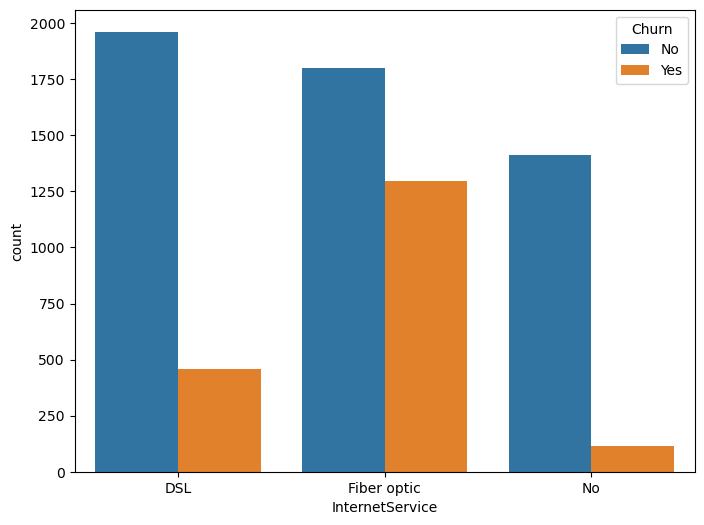

In [16]:
plt.figure(figsize=(8,6))

sns.countplot( x="InternetService", hue="Churn", data=df)
plt.savefig(
    "screenshots/internetservice_vs_churn.png"
)
plt.show()

### Observations:
- Customers with fiber optic services churn more.
- Customers with DSL services churn less compared to others.

## Payment Method Analysis

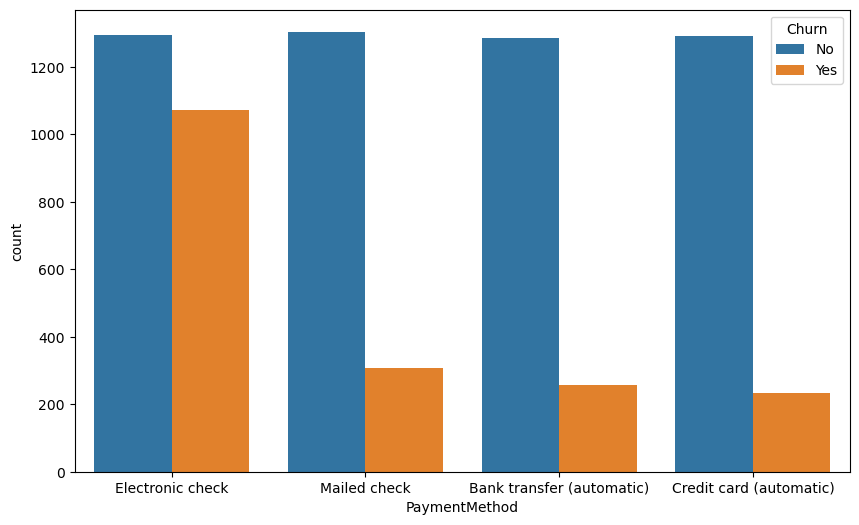

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.savefig(
    "screenshots/paymentmethod_vs_churn.png"
)
plt.show()

### Observation:
- Customers with electronic check payment method tend to churn more.

## Correlation Analysis

In [18]:
df["ChurnNumeric"] = df["Churn"].map({"No":0, "Yes":1})

In [19]:
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "ChurnNumeric"]

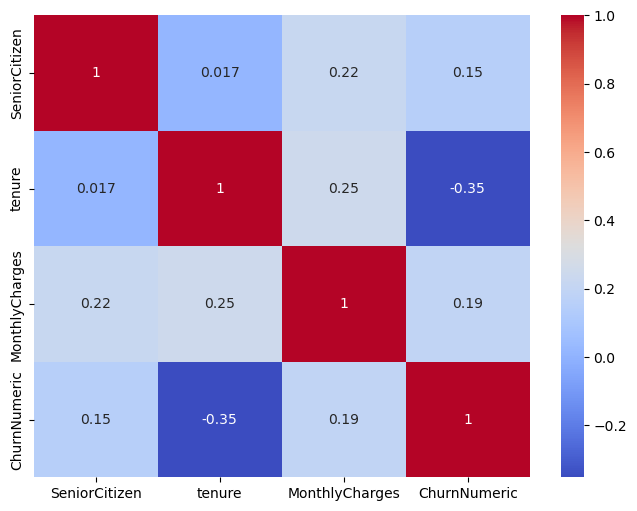

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap( df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.savefig(
    "screenshots/correlation_heatmap.png"
)
plt.show()

### Observations:
- Customers who stay with the company for a longer time are less likely to churn.
- Higher monthly bills may contribute to customer churn.
- Senior citizens appear slightly more likely to churn compared to non-senior customers.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
ChurnNumeric        0
dtype: int64

In [23]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

## Data Cleaning

In [24]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [25]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [26]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
df.dropna(inplace=True)

In [29]:
df.shape

(7032, 22)

In [30]:
df = df.drop("customerID", axis=1)

# EDA Analysis:
- Around 26% customers churned while about 74% stayed.
- Customers with low tenure churn more frequently.
- Tenure appears to be one of the strongest predictors of churn.
- Customers with higher monthly charges show higher churn tendency.
- Month-to-month contracts have significantly higher churn compared to one-year and two-year contracts.
- Logistic Regression was selected as the final model after model comparison (implemented in compare_models.py and train.py).